<a href="https://colab.research.google.com/github/Andrian0s/ML4NLP1-2024-Tutorial-Notebooks/blob/main/exercises/ex1/ex1_lr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML4NLP1

## Starting Point for Exercise 1, part I

This notebook is supposed to serve as a starting point and/or inspiration when starting exercise 1, part I.

One of the goals of this exercise is to get you acquainted with sklearn and related libraries like pandas and numpy. You will probably need to consult the documentation of those libraries:
- sklearn: [Documentation](https://scikit-learn.org/stable/user_guide.html)
- Pandas: [Documentation](https://pandas.pydata.org/docs/#)
- NumPy: [Documentation](https://numpy.org/doc/)
- SHAP: [Documentation](https://shap.readthedocs.io/en/latest/index.html)

## Task Description

Follow the instructions in this notebook to:

1. Explore the data and create training/test splits for your experiments

2. Build a LogisticRegression classifier and design some relevant features to apply it to your data

3. Conduct hyperparameter tuning to find the optimal hyperparameters for your model

4. Explore your model's predictions and conduct an error analysis to see where the model fails

5. Conduct an interpretability analysis, investigating the model's most important features.

6. Conduct an ablation study using a subset of languages


Throughout the notebook, there are questions that you should address in your report. These are marked with 🗒❓.

☝ Note, these questions are intended to provide you with an opportunity to reflect on what it is that you are doing and the kind of challenges you might face along the way.




---

### Declaration of Usage of Generative AI
In this work, Generative AI was used to refine the wording of **some** written paragraphs and comments, including the ones in the final report, to improve their clarity and style, as English is not the native language of any of the group members. The underlying ideas and content remain entirely our own. In terms of coding, AI assistance was limited **only** to the cell for setting up the font compatible with different alphabets to visualise SHAP values. **No** generative AI tools were used as a learning assistant during the completion of this exercise.

---

In [1]:
import pandas as pd
import numpy as np

# Set seed for reproducibility
np.random.seed(42)

### Loading the datasets

In [2]:
# Download dataset
!gdown 1QP6YuwdKFNUPpvhOaAcvv2Pcp4JMbIRs # x_train
!gdown 1QVo7PZAdiZKzifK8kwhEr_umosiDCUx6 # x_test
!gdown 1QbBeKcmG2ZyAEFB3AKGTgSWQ1YEMn2jl # y_train
!gdown 1QaZj6bI7_78ymnN8IpSk4gVvg-C9fA6X # y_test

Downloading...
From: https://drive.google.com/uc?id=1QP6YuwdKFNUPpvhOaAcvv2Pcp4JMbIRs
To: /content/x_train.txt
100% 64.1M/64.1M [00:00<00:00, 155MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QVo7PZAdiZKzifK8kwhEr_umosiDCUx6
To: /content/x_test.txt
100% 65.2M/65.2M [00:00<00:00, 140MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QbBeKcmG2ZyAEFB3AKGTgSWQ1YEMn2jl
To: /content/y_train.txt
100% 480k/480k [00:00<00:00, 81.5MB/s]
Downloading...
From: https://drive.google.com/uc?id=1QaZj6bI7_78ymnN8IpSk4gVvg-C9fA6X
To: /content/y_test.txt
100% 480k/480k [00:00<00:00, 25.5MB/s]


In [3]:
with open(f'x_train.txt') as f:
    x_train = f.read().splitlines()
with open(f'y_train.txt') as f:
    y_train = f.read().splitlines()
with open(f'x_test.txt') as f:
    x_test = f.read().splitlines()
with open(f'y_test.txt') as f:
    y_test = f.read().splitlines()

In [4]:
# Combine x_train and y_train into one dataframe
train_df = pd.DataFrame({'text': x_train, 'label': y_train})

# Write train_df to csv with tab as separator
train_df.to_csv('train_df.csv', index=False, sep='\t')

# Combine x_test and y_test into one dataframe
test_df = pd.DataFrame({'text': x_test, 'label': y_test})

# Inspect the first 5 items in the train split
train_df.head()

,text,label
0,Klement Gottwaldi surnukeha palsameeriti ning ...,est
1,"Sebes, Joseph; Pereira Thomas (1961) (på eng)....",swe
2,भारतीय स्वातन्त्र्य आन्दोलन राष्ट्रीय एवम क्षे...,mai
3,"Après lo cort periòde d'establiment a Basilèa,...",oci
4,ถนนเจริญกรุง (อักษรโรมัน: Thanon Charoen Krung...,tha


In [5]:
# Get list of all labels
labels = train_df['label'].unique().tolist()
print(labels)

['est', 'swe', 'mai', 'oci', 'tha', 'orm', 'lim', 'guj', 'pnb', 'zea', 'krc', 'hat', 'pcd', 'tam', 'vie', 'pan', 'szl', 'ckb', 'fur', 'wuu', 'arz', 'ton', 'eus', 'map-bms', 'glk', 'nld', 'bod', 'jpn', 'arg', 'srd', 'ext', 'sin', 'kur', 'che', 'tuk', 'pag', 'tur', 'als', 'koi', 'lat', 'urd', 'tat', 'bxr', 'ind', 'kir', 'zh-yue', 'dan', 'por', 'fra', 'ori', 'nob', 'jbo', 'kok', 'amh', 'khm', 'hbs', 'slv', 'bos', 'tet', 'zho', 'kor', 'sah', 'rup', 'ast', 'wol', 'bul', 'gla', 'msa', 'crh', 'lug', 'sun', 'bre', 'mon', 'nep', 'ibo', 'cdo', 'asm', 'grn', 'hin', 'mar', 'lin', 'ile', 'lmo', 'mya', 'ilo', 'csb', 'tyv', 'gle', 'nan', 'jam', 'scn', 'be-tarask', 'diq', 'cor', 'fao', 'mlg', 'yid', 'sme', 'spa', 'kbd', 'udm', 'isl', 'ksh', 'san', 'aze', 'nap', 'dsb', 'pam', 'cym', 'srp', 'stq', 'tel', 'swa', 'vls', 'mzn', 'bel', 'lad', 'ina', 'ava', 'lao', 'min', 'ita', 'nds-nl', 'oss', 'kab', 'pus', 'fin', 'snd', 'kaa', 'fas', 'cbk', 'cat', 'nci', 'mhr', 'roa-tara', 'frp', 'ron', 'new', 'bar', 'ltg'


### 1.1 Exploring the training data

📝❓Take a look at a couple of texts from different languages and answer the following questions:


In [6]:
# First, we take a look at a couple of texts from different languages.
# Define the languages of interest
labels = ['eng', 'deu', 'nld', 'dan', 'mai', 'rus', 'jpn']

def sample_texts(train_df: pd.DataFrame,
                 labels: list) -> None:
  # Filter the training data
  train_df1 = train_df[train_df['label'].isin(labels)].copy()

  # Show two random examples per language
  for lang, group in train_df1.groupby('label'):
    samples = group['text'].sample(2).to_list()
    print(f"\n--- {lang.upper()} ---")
    for s in samples:
      print("-", s)

sample_texts(train_df, labels)


--- DAN ---
- Ruffel: Kvinde, i live. Oprindeligt introduceret sammen med Maleen og Vurdah som en af tre unavngivne elverpiger, som var sammen med Ulverytteren Tyde. Hun fik sit navn i en kort historie "Hjertets Veje", der fortalte mere detaljeret om deres forhold. Hun har bølget rødt hår og foretrækker lette, flagrende kjoler.
- Filmen begynder med at Optimus Prime, de venlige Autobotters heroiske leder, i en voice-over beskriver undergangen af Transformernes hjem verden, Cybertron. Den blev destrueret af den one Decepticon leder Megatron i hans søgen efter Urgnisten. Autobotterne vil finde Urgnisten så de kan bruge den til at genopbygge Cybertron og ende krigen mellem dem selv og Decepticonerne, mens Decepticonerne vil bruge den til at overvinde Autobotterne og erobre universet. Megantron fandt Urgnisten på Jorden, men nødlandede i Polarcirklen og blev frosset inde i isen. Kaptajn Witwicky og hans besætning af opdagelsesrejsende snublede over Megatrons krop i 1897. Kaptajn Witwicky 

1. Do you notice anything that might be challenging for the classification?

In [7]:
# We take a look at the languages from the same language branch of a language family.
# For instance, Scandinavian languages such as Danish, Swedish and Norwegian
# are known to be close
labels = ['dan', 'swe', 'nob']
sample_texts(train_df, labels)


--- DAN ---
- Dominic Anthony Sherwood (Dom Sherwood) (født 6. februar 1990) er en engelsk skuespiller og model. Han er kendt for sin rolle i teenagevampyrfilmen Vampire Academy og for sin rolle som Jace Herondale i Freeform og Netflix-serien Shadowhunters.
- Mange millenaristiske bevægelser er opstået i forbindelse med ’’runde årstal’’, som det fx skete omkring år 1000 i Vesteuropa. Op til årtusindskiftet omkring år 2000 blev bl.a. organisationen Millenium Watch Institute etableret for at overvåge de milenaristiske grupper, man mente ville opstå i forbindelse med denne begivehed.

--- NOB ---
- Skottland (engelsk/skotsk: Scotland, skotsk gælisk: Alba) er en selvstyrt nasjon i det nordvestlige Europa og en av de fire nasjonene som utgjør Det forente kongerike Storbritannia og Nord-Irland. Skottland er den nest største delen (med 32 % av flaten og 8 % av befolkningen) etter England, fulgt av Wales og Nord-Irland. Det geografiske området består av den nordlige tredjedelen av øya Storbri

✅ The languages that share significant linguistic similarities in vocabulary and grammar might be challenging to distinguish for a simple classification algorithm.

2. How is the data distributed? (i.e., how many instances per label are there in the training and test set? Is it a balanced dataset?)

In [8]:
# Number of instances per label in training and test sets
pd.DataFrame({
    'train': train_df['label'].value_counts().sort_index(),
    'test':  test_df['label'].value_counts().sort_index()
})

,train,test
label,,
ace,500,500
afr,500,500
als,500,500
amh,500,500
ang,500,500
...,...,...
yid,500,500
yor,500,500
zea,500,500


✅ Each label has 500 samples in both the training and test sets. We would claim that the dataset is perfectly balanced across all classes.

3. Do you think the train/test split is appropriate (i.e., is the test data representative of the training data)? If not, please rearrange the data in a more appropriate way.

In [9]:
# Number non-NA rows for each column in training and test sets
pd.DataFrame({
    'train': train_df.count(),
    'test': test_df.count()
})

,train,test
text,117500,117500
label,117500,117500


✅ The test data is representative of the training data, as the test set covers all classes from the training set, each class has an equal number of examples, and every row includes both text and label with no missing values. However, a 50/50 split leaves too little data for training and more test data to evaluate the performance than actually is needed. To fix this, we concatenate the current train and test sets, then perform a new random 80/20 split and stratify by label for keep class balance.

In [10]:
from sklearn.model_selection import train_test_split

# Concatenate train and test set
df = pd.concat([train_df, test_df])

# Create a new 80/20 stratified split
train_df, test_df = train_test_split(df,
                                     test_size=0.2,
                                     random_state=42,
                                     stratify=df['label'])

# Number of instances per label in training and test sets
pd.DataFrame({
    'train': train_df['label'].value_counts().sort_index(),
    'test':  test_df['label'].value_counts().sort_index()
})


,train,test
label,,
ace,800,200
afr,800,200
als,800,200
amh,800,200
ang,800,200
...,...,...
yid,800,200
yor,800,200
zea,800,200


### 1.2 Data preparation

Get a subset of the train/test data that includes 20 languages.
Include English, German, Dutch, Danish, Swedish, Norwegian, and Japanese, plus 13 additional languages of your choice based on the items in the list of labels.

In [11]:
# Define the languages of interest
labels = ['eng', 'deu', 'nld', 'dan', 'swe', 'nob', 'jpn', 'est', 'kir', 'lat',
          'tat', 'ukr', 'tha', 'spa', 'isl', 'aze', 'hrv', 'hun', 'pol', 'ita']

# Create our train/test subsets of languages
train_df_sub = train_df[train_df['label'].isin(labels)].copy()
test_df_sub = test_df[test_df['label'].isin(labels)].copy()

# Number of instances per label in training and test sets
pd.DataFrame({
    'train': train_df_sub['label'].value_counts().sort_index(),
    'test':  test_df_sub['label'].value_counts().sort_index()
})

,train,test
label,,
aze,800,200
dan,800,200
deu,800,200
eng,800,200
est,800,200
hrv,800,200
hun,800,200
isl,800,200
ita,800,200


In [12]:
# To encode the labels, first fit the encoder on the training labels,
# then apply transform to both training and test labels (the provided
# code fitted three times, even on test labels).
# However, since we took the subset of the dataset, we will be working
# with the labels from that subset
from sklearn.preprocessing import LabelEncoder

# Fit encoder on training labels
label_encoder = LabelEncoder().fit(train_df_sub['label'])

# Transform train and test labels
train_df_sub['target'] = label_encoder.transform(train_df_sub['label'])
test_df_sub['target'] = label_encoder.transform(test_df_sub['label'])

# Report the results
print("The labels for each class:", label_encoder.classes_)
print("Encoded training labels:", train_df_sub['target'].to_numpy())
print("Encoded test labels:", test_df_sub['target'].to_numpy())

The labels for each class: ['aze' 'dan' 'deu' 'eng' 'est' 'hrv' 'hun' 'isl' 'ita' 'jpn' 'kir' 'lat'
 'nld' 'nob' 'pol' 'spa' 'swe' 'tat' 'tha' 'ukr']
Encoded training labels: [ 9 15  6 ... 19  7  9]
Encoded test labels: [ 0 13 13 ... 19  0 13]


### 2.1 Build a LogisticRegression classifier

To start with, we're going to build a very simple LogisticRegression classifier.
Use a `Pipeline` to chain togther a `CountVectorizer` and a `LogisticRegression` estimator. Then perform a 5-fold cross validation and report the scores of this model as a baseline.

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import CountVectorizer

# Define a very basic pipeline using a CountVectorizer and a LogisticRegression classifier
pipeline = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', LogisticRegression())
])

In [14]:
from sklearn.model_selection import cross_validate

# Run a cross validation to estimate the model's expected performance
result = cross_validate(pipeline,
                        train_df_sub['text'],
                        train_df_sub['target'],
                        scoring='accuracy',
                        cv=5,
                        n_jobs=-1)

# Report the scores
scores = result['test_score']
print(f"CV scores on {len(scores)} folds: {scores}")
print(f"Average CV score: {scores.mean()}")

CV scores on 5 folds: [0.9584375 0.956875  0.96      0.9578125 0.9584375]
Average CV score: 0.9583124999999999



### 2.2 Feature Engineering

So far, we've only considered the basic `CountVectorizer` at the word level to encode our input texts for our model.

Your task is to apply some text preprocessing and engineer some more informative features.

To do this, think about what other features might be relevant for determining the language of an input text.

Define a custom set of feature extractors and implement the necessary preprocessing steps to extract these features from strings.

Then initialise a processing pipeline that converts your input data into features that the model can take as input.

☝ Note, this step can be as involved as your heart desires, there is only one minimal requirement: you must use something more than the base `CountVectorizer`. We recommend that you take a look at the [`BaseEstimator`](https://scikit-learn.org/stable/modules/generated/sklearn.base.BaseEstimator.html) and [`TransformerMixin`](https://scikit-learn.org/stable/modules/generated/sklearn.base.TransformerMixin.html#transformermixin) classes from `sk-learn`, as these can be helpful for defining custom transformers.


In [15]:
# First, we create a preprocessor which takes an input text, replaces
# missing values with an empty string, applies NFKC normalization to
# bring characters into a consistent form, converts the text to
# lowercase, and then reduces all consecutive whitespace characters
# to a single space
import unicodedata
from typing import Iterable, Union
from sklearn.base import BaseEstimator, TransformerMixin

class Preprocessor(BaseEstimator, TransformerMixin):
    def fit(self, X: Iterable[str],
            y: Union[Iterable, None] = None):
        return self

    def transform(self,
                  X: Iterable[Union[str, None]]) -> list[str]:
        out = []
        for text in X:

            # Replace missing values with an empty string
            text = '' if text is None else str(text)

            # Normalize characters into a consistent form
            text = unicodedata.normalize('NFKC', text)

            # Convert to lowercase
            text = text.lower()

            # Collapse consecutive whitespace into a single one
            text = ' '.join(text.split())

            out.append(text)
        return out

In [16]:
# Secondly, we introduce text length in symbols as a custom feature. Languages differ
# in how many characters they use to express similar content due to variations in word
# formation. For example, Japanese conveys more meaning per symbol, while German uses
# longer words

class FeatureExtractor(BaseEstimator,TransformerMixin):
  def fit(self, X: Iterable[str],
          y: Union[Iterable, None] = None):
    return self

  def transform(self,
                X: Iterable[Union[str, None]]) -> list[list[int]]:
    return [[len(text)] for text in X]

In [17]:
# Finally, we use a character-level TF-IDF vectorizer to extract meaningful features.
# The main idea is that languages can be separated by their alphabets and by
# characteristic diacritics (e.g., ä, ü, ö in German). Also, for hieroglyphic
# languages such as Japanese, characters carry meaning and words are not
# space-delimited, making token-level features senseless. The languages using
# the same alphabet can be still distinguished by characteristic n-grams and word
# frequencies. Unlike simple word counts, which overemphasize frequent function
# words (e.g., “a”, “the” in English or “der”, “die”, “das” in German), TF-IDF
# down-weights characters/n-grams common across documents and highlights
# language-specific signals
from sklearn.pipeline import FeatureUnion
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

# We omit TF-IDF’s default preprocessing, use character n-grams up to length 3,
# and train a Logistic Regression on these features to classify the texts. We
# set max_features to 1000 to reduce the computation time
pipeline = Pipeline(
    [('preprocessor', Preprocessor()),
     ('features',FeatureUnion([
                ('text_length', FeatureExtractor()),
                ('vectorizer', TfidfVectorizer(analyzer='char_wb',  # n-grams within word boundaries
                                               ngram_range=(1, 3),
                                               max_features=1000,
                                               lowercase=False,
                                               strip_accents=None,
                                               preprocessor=None,
                                               tokenizer=None,
                                               dtype=np.float32  # save memory
                                               ))])),
     ('classifier', LogisticRegression())
    ])

---

### 3.1 Grid Search

Use sklearn's GridSearchCV and experiment with the following hyperparameters:
1. Penalty (Regularization)
2. Solver
3. Experiment with parameters of the Vectorizer (optional, but highly advised)

☝ Note, don't overdo it at the beginning, since runtime might go up fast!

Make sure you read through the [docs](https://scikit-learn.org/1.5/modules/generated/sklearn.linear_model.LogisticRegression.html#logisticregression) to get an understanding of what these parameters do.


In [18]:
# The 'penalty' hyperparameter selects the type of regularization,
# but not all penalties work with all solvers. The 'solver' selects
# the optimization algorithm. According to the scikit-learn documentation,
# 'sag' and 'saga' are typically faster on large datasets. For true
#  multinomial (softmax) logistic regression, only 'newton-cg', 'lbfgs',
# 'sag', and 'saga' are supported, whereas 'liblinear' uses one-vs-rest
#  and does not optimize the multinomial loss
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'classifier__penalty': ['l2', None],
    'classifier__solver': ['newton-cg', 'saga']
}

# Grid search with 5-fold cross-validation optimizing accuracy
gs_pipeline = GridSearchCV(pipeline,
                           param_grid,
                           scoring='accuracy',
                           cv=5,
                           n_jobs=-1,
                           verbose=1)
gs_pipeline.fit(train_df_sub['text'], train_df_sub['target'])

Fitting 5 folds for each of 4 candidates, totalling 20 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor', Preprocessor()),
                                       ('features',
                                        FeatureUnion(transformer_list=[('text_length',
                                                                        FeatureExtractor()),
                                                                       ('vectorizer',
                                                                        TfidfVectorizer(analyzer='char_wb',
                                                                                        dtype=<class 'numpy.float32'>,
                                                                                        lowercase=False,
                                                                                        max_features=1000,
                                                                                        ngram_range=(1,
                                                                                                     3)))])),
                                       ('classifier', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'classifier__penalty': ['l2', None],
                         'classifier__solver': ['newton-cg', 'saga']},
             scoring='accuracy', verbose=1)

### 3.2 Best Model Selection

After conducting our Grid Search, we should be able to identify our best model by inspecting the using the Grid Search result attribute `cv_results_`. (Hint: `cv_results_` returns a dictionay, so convert it to a Pandas Dataframe for easy inspection.)

In [19]:
# Inspect the results of the Grid Search
gs_df = pd.DataFrame.from_dict(gs_pipeline.cv_results_)
gs_df.sort_values(by=['rank_test_score'])

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_classifier__penalty,param_classifier__solver,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
2,323.138434,21.445844,4.343829,0.652517,None,newton-cg,"{'classifier__penalty': None, 'classifier__sol...",0.983437,0.984375,0.983437,0.985000,0.981875,0.983625,0.001057,1
0,126.719586,11.979693,3.673708,0.179391,l2,newton-cg,"{'classifier__penalty': 'l2', 'classifier__sol...",0.979062,0.976875,0.978125,0.979688,0.975313,0.977813,0.001569,2
1,59.722256,3.592152,4.127569,0.738289,l2,saga,"{'classifier__penalty': 'l2', 'classifier__sol...",0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.000000,3
3,58.449138,2.653976,3.376516,0.759535,None,saga,"{'classifier__penalty': None, 'classifier__sol...",0.050000,0.050000,0.050000,0.050000,0.050000,0.050000,0.000000,3


📝❓ What were the hyperparameter combinations for your best-performing model on the test set.


In [20]:
print(f"Best hyperparameter combination: {gs_pipeline.best_params_} "
      f"with a cross-validation score of {gs_pipeline.best_score_}")

Best hyperparameter combination: {'classifier__penalty': None, 'classifier__solver': 'newton-cg'} with a cross-validation score of 0.983625


✅ The best performing model used no penalty and 'newton-sg' solver.

📝❓ What is the advantage of grid search cross-validation?

✅ Grid search with cross-validation evaluates each hyperparameter across multiple folds, so every sample is used for validation exactly once. This process helps select hyperparameters that are less influenced by split-specific variance, thus leading to better generalization.

## 3.3 Model Evaluation

Once you have identified your best model, use it to predict the languages of texts in the test split.

📝❓ According to standard metrics (e.g. Accurracy, Precision, Recall and F1), how well does your model perform on the heldout test set?


In [21]:
# If we use gs_pipeline.best_estimator_.predict(test_df_sub['text']), we will not
# make use of the whole training set. Using the best hyperparameters found through
# grid search with cross-validation, we retrain the pipeline on the full training
# set before evaluating it on the test set
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report)

# Configure the pipeline with the best-found hyperparameters
pipeline = Pipeline(
    [('preprocessor', Preprocessor()),
     ('features',FeatureUnion([
                ('text_length', FeatureExtractor()),
                ('vectorizer', TfidfVectorizer(analyzer='char_wb',
                                               ngram_range=(1, 3),
                                               max_features=1000,
                                               lowercase=False,
                                               strip_accents=None,
                                               preprocessor=None,
                                               tokenizer=None,
                                               dtype=np.float32
                                               ))])),
     ('classifier', LogisticRegression(penalty=None,
                                       solver='newton-cg'))
    ])

# Train the model on the entire training set
pipeline.fit(train_df_sub['text'], train_df_sub['target'])

# Generate predictions on the held-out test set
y_pred = pipeline.predict(test_df_sub['text'])

# Evaluate model performance using accuracy, precision, recall, and F1 score
print(f"Accuracy: {accuracy_score(test_df_sub['target'], y_pred)}")
print(f"Precision: {precision_score(test_df_sub['target'], y_pred, average='macro')}")
print(f"Recall: {recall_score(test_df_sub['target'], y_pred, average='macro')}")
print(f"F1 Score: {f1_score(test_df_sub['target'], y_pred, average='macro')}")

# Print a detailed report per class
print("\nClassification Report:\n")
print(classification_report(test_df_sub['target'], y_pred,
                            target_names=label_encoder.classes_, digits=3))


Accuracy: 0.9815
Precision: 0.9817380497703496
Recall: 0.9814999999999998
F1 Score: 0.9815313396034668

Classification Report:

              precision    recall  f1-score   support

         aze      1.000     0.980     0.990       200
         dan      0.969     0.950     0.960       200
         deu      0.970     0.985     0.978       200
         eng      0.943     0.990     0.966       200
         est      0.974     0.940     0.957       200
         hrv      0.995     0.985     0.990       200
         hun      0.995     0.990     0.992       200
         isl      1.000     1.000     1.000       200
         ita      0.985     0.980     0.982       200
         jpn      0.995     0.975     0.985       200
         kir      0.980     0.985     0.983       200
         lat      0.937     0.970     0.953       200
         nld      0.985     0.985     0.985       200
         nob      0.956     0.970     0.963       200
         pol      0.995     0.995     0.995       200
       

✅ The model performs very well on the held-out test set, exceeding **0.98** in accuracy, precision, recall, and F1 score.

---

### 4.1 Error Analysis

Inspect your model's predictions using a confusion matrix and provide a summary of what you find in your report.

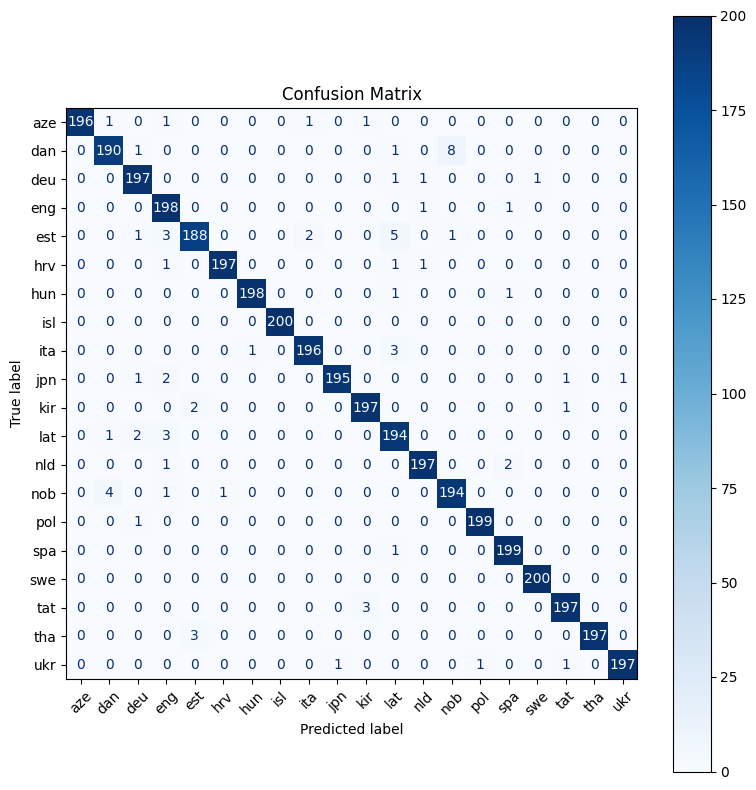

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute the confusion matrix for the model's predictions
cm = confusion_matrix(test_df_sub['target'], y_pred)

# Display the confusion matrix as a heatmap
fig, ax = plt.subplots(figsize=(8, 8), dpi=100)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=label_encoder.classes_)
disp.plot(cmap='Blues', xticks_rotation=45, ax=ax)
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

📝❓ Where does your model do well and where does it fail?

✅ The model performs exceptionally well across nearly all languages, as evidenced by the diagonal values ranging between 188 and 200 out of 200. Languages with distinct alphabets or unique characters are classified almost perfectly, e.g. Thai (`tha`). Among Latin-based languages, the strong diagonal dominance remains, though a few noticeable off-diagonal values reveal where the model struggles. For instance, confusion occurs between Danish (`dan`) and Norwegian (`nob`), as well as between Latin (`lat`) and Italian (`ita`), which was expected given their similarities.

📝❓ What are some possible reasons for why it fails in these cases?

✅ The model likely struggles in these cases because the languages share the same alphabet and have very similar grammar, which makes their character patterns overlap in the TF-IDF features. Additionally, these misclassified texts may simply be too short to contain enough distinctive information to identify the language.

---

### 5.1 Interpretability Analysis

Now that you have your best model, it's time to dive deep into understanding how the model makes predictions.

It is important that we can explain and visualise our models to improve task performance. Explainable models help characterise model fairness, transparency, and outcomes.

Let's try to understand what our best-performing logistic regression classification model has learned.

Inspect the 20 most important features for the languages English, Swedish, Norwegian, and Japanese. Please make sure that the features are named and human-interpretable, not things like "Feat_1". (Hint: if you have used custom feature extractors in your pipeline, you may need to adapt these to make sure that the feature names are maintained.)

We recommend using the [SHAP library](https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/linear_models/Sentiment%20Analysis%20with%20Logistic%20Regression.html) as discussed in the tutorial. We've provided an example notebook for working with SHAP for multi-class classification in the course GitHub repo.

☝ Note, if you prefer to use another interpretability tool, we will accept answers from any explanation library/method as long as the explanations for the model weights are provided in a structured/clear way.



In [23]:
# To use shap, we first need to install it into the current environment
!pip install --upgrade shap

import shap

In [24]:
# Firstly, we retrieve the feature names from the vectorizer and include our
# additional feature "text_length", i.e. the text length in symbols
vectorizer = pipeline.named_steps['features'].transformer_list[1][1]
feature_names = ['text_length'] + vectorizer.get_feature_names_out().tolist()

# Print the total number of features and their names
print(f"Number of the features: {len(feature_names)}")
print("Names of the features:", feature_names)

Number of the features: 1001
Names of the features: ['text_length', ' ', ' "', ' (', ' 1', ' 19', ' 2', ' 20', ' a', ' a ', ' af', ' al', ' an', ' ar', ' at', ' au', ' av', ' b', ' ba', ' be', ' bi', ' bl', ' br', ' c', ' ca', ' ch', ' co', ' d', ' da', ' de', ' di', ' do', ' e', ' ei', ' el', ' en', ' er', ' es', ' et', ' f', ' fa', ' fe', ' fi', ' fo', ' fr', ' g', ' ge', ' gr', ' h', ' ha', ' he', ' hi', ' ho', ' i', ' i ', ' il', ' in', ' is', ' j', ' ja', ' je', ' k', ' ka', ' ki', ' ko', ' l', ' la', ' le', ' li', ' lo', ' m', ' ma', ' me', ' mi', ' mo', ' n', ' na', ' ne', ' ni', ' no', ' o', ' of', ' og', ' ol', ' on', ' op', ' or', ' p', ' pa', ' pe', ' po', ' pr', ' q', ' qu', ' r', ' ra', ' re', ' ro', ' s', ' sa', ' se', ' si', ' sk', ' so', ' sp', ' st', ' su', ' t', ' ta', ' te', ' th', ' ti', ' to', ' tr', ' u', ' un', ' v', ' va', ' ve', ' vi', ' vo', ' w', ' w ', ' wa', ' we', ' wi', ' y', ' z', ' za', ' á', ' ä', ' í', ' þ', ' а', ' б', ' ба', ' в', ' д', ' ж', ' з', 

In [25]:
# Secondly, we transform the training and test texts using all transformation steps
# from the pipeline (excluding the classifier). We then initialize a SHAP explainer
# with the classifier and transformed features to identify the 20 most important features
# according to SHAP values. These values measure the contribution of the features towards
# the prediction

# Create a function that applies the pipeline transformations
def pipeline_transform(X: Iterable[str]) -> np.ndarray:
    return pipeline[:-1].transform(X).toarray()

# Initialize SHAP explainer
explainer = shap.Explainer(pipeline.named_steps['classifier'],
                           pipeline_transform(train_df_sub['text']),
                           feature_names=feature_names)

# Calculate SHAP values for the test set
shap_values = explainer(pipeline_transform(test_df_sub['text']))


/usr/local/lib/python3.12/dist-packages/sklearn/pipeline.py:62: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


In [26]:
# While plotting SHAP values, we noticed that some characters (e.g., Japanese glyphs)
# appeared as white boxes due to font incompatibility. To fix this, we install a font
# that supports Latin, Cyrillic, and Japanese scripts.

!apt-get install -y fonts-noto-cjk

import os, shutil
import matplotlib
import matplotlib.font_manager as fm

cache_dir = matplotlib.get_configdir() + "/fonts"
if os.path.exists(cache_dir):
    shutil.rmtree(cache_dir)

fm.findSystemFonts()
fm.fontManager.addfont("/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc")

matplotlib.rcParams["font.family"] = "Noto Sans CJK JP"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-cjk is already the newest version (1:20220127+repack1-1).
0 upgraded, 0 newly installed, 0 to remove and 38 not upgraded.


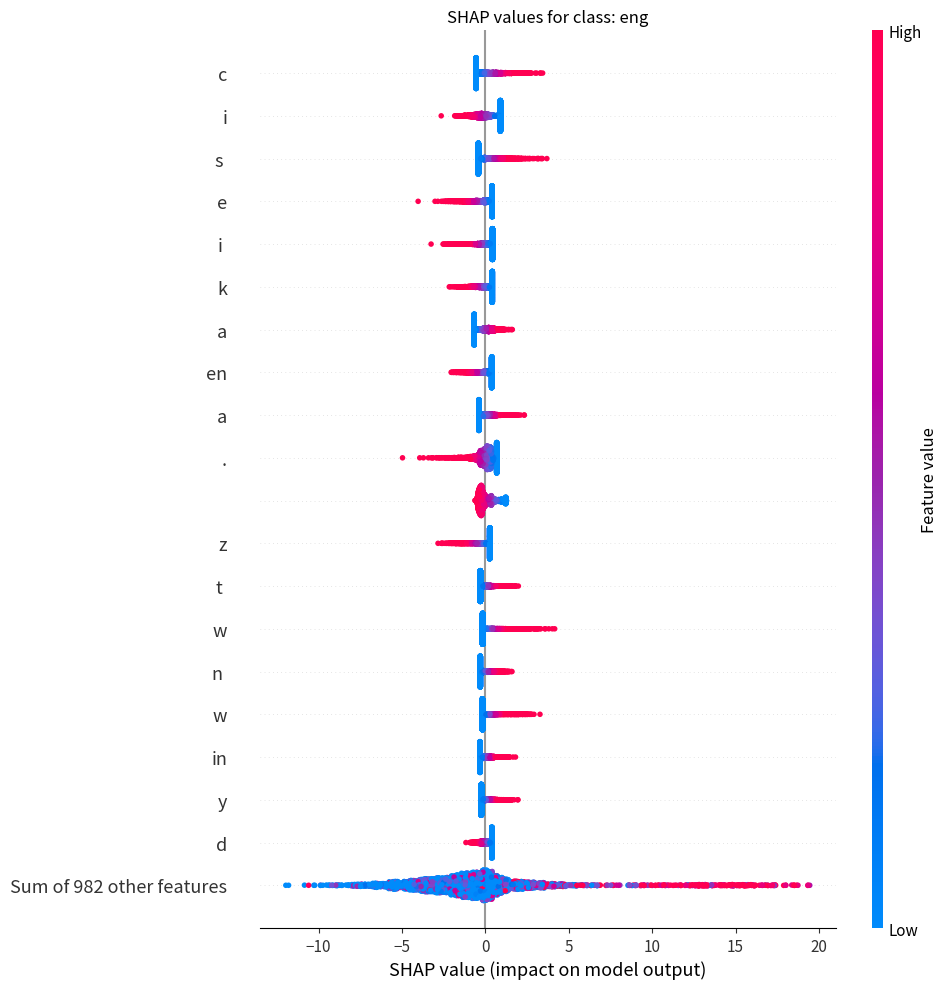

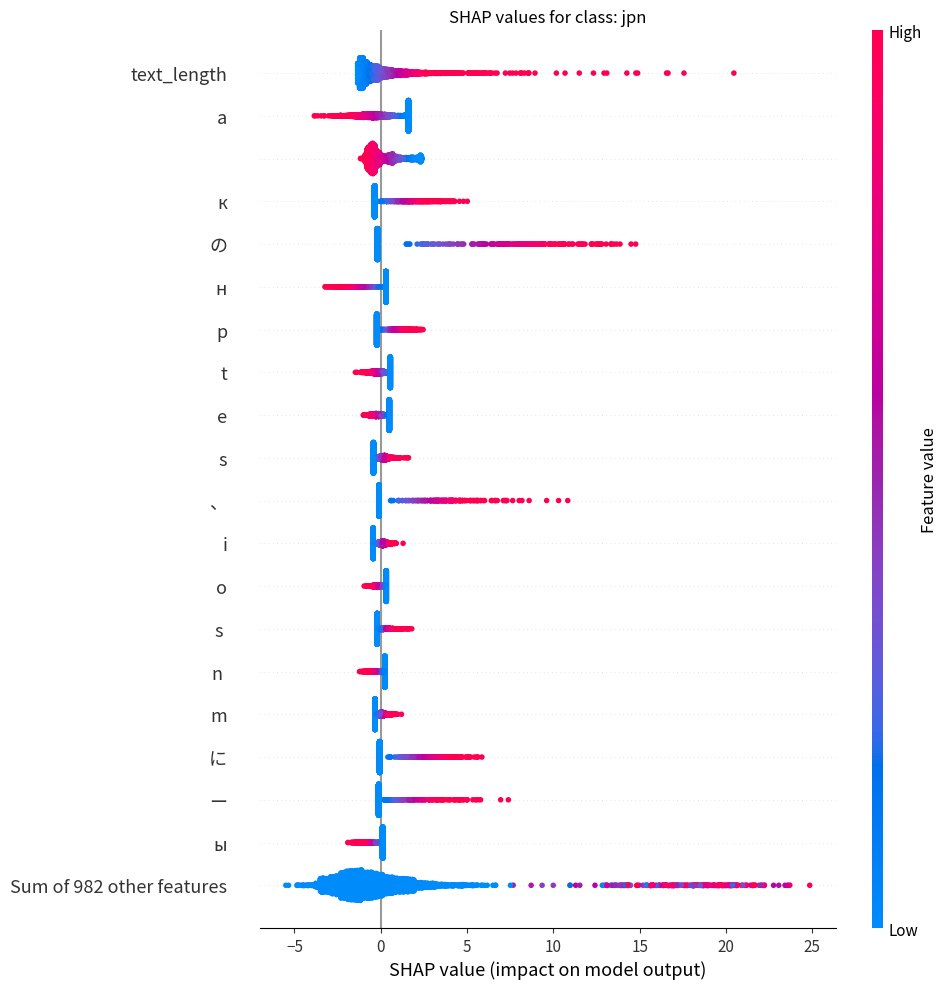

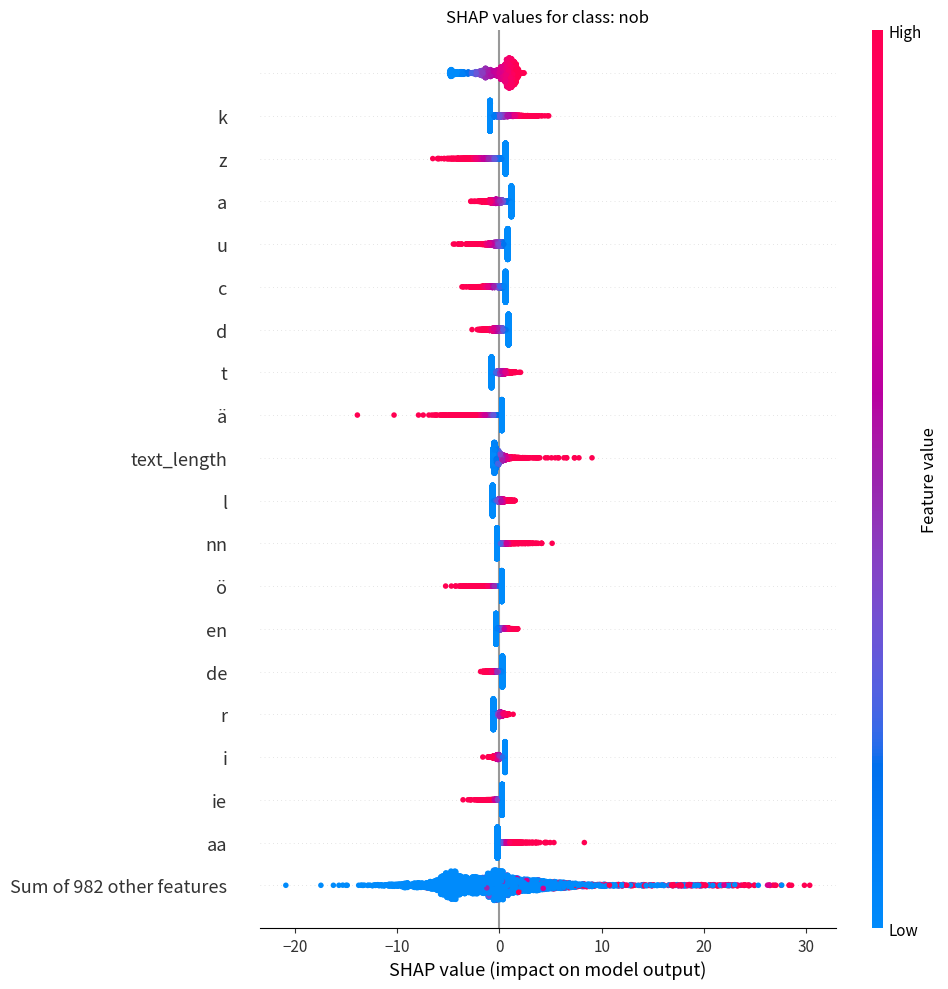

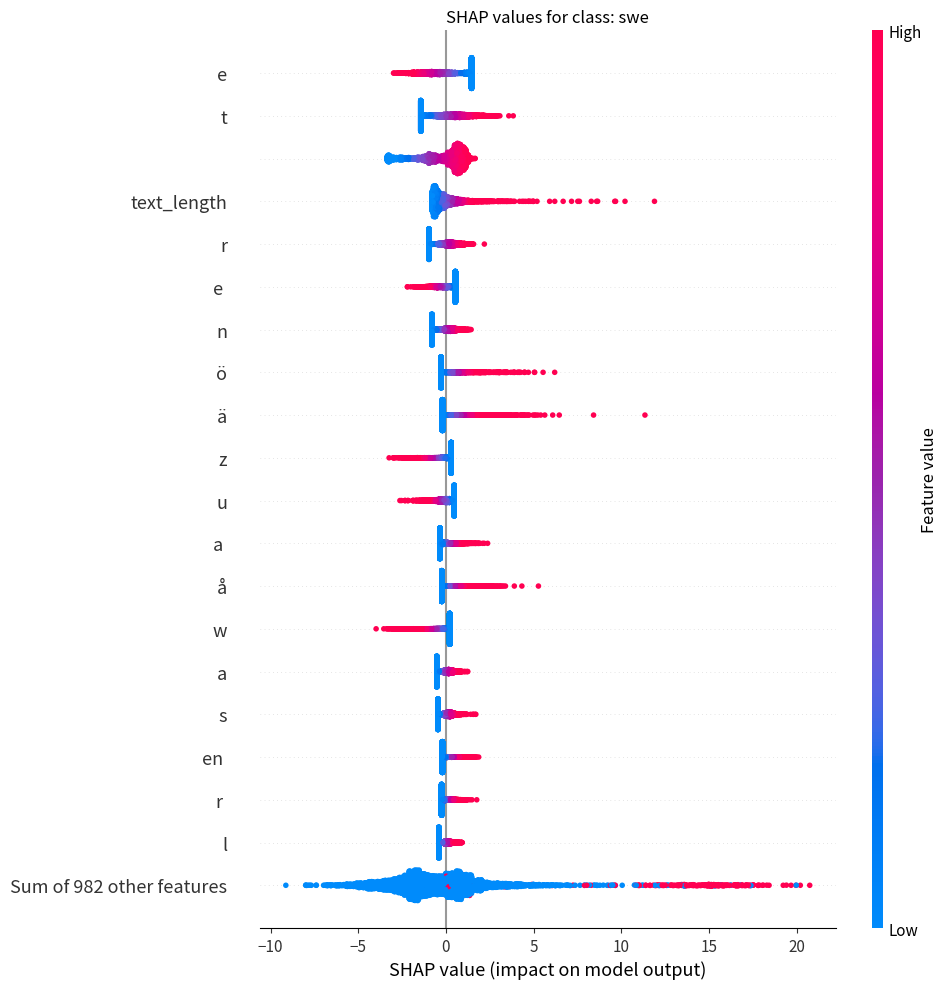

In [27]:
# Finally, we visualize the SHAP values of the 20 most important features for
# English, Swedish, Norwegian, and Japanese prediction using a beeswarm plot

# Get the names of the classes
categories = label_encoder.classes_

# Create beeswarm plots
for i, category in enumerate(categories):
    if category in ['eng', 'swe', 'nob', 'jpn']:
      figsize = (10, 10)
      plt.figure(figsize=figsize)
      shap.plots.beeswarm(shap_values[:, :, i], max_display=20, show=False, plot_size=figsize)
      plt.title(f"SHAP values for class: {category}")
      plt.tight_layout()
      plt.show()

📝❓ What is more important, extra features or the outputs of the vectorizer? Please discuss.

✅ The outputs of the TF-IDF vectorizer mainly appear to be more influential overall than the additional "text length" feature. However, for Japanese, text length emerges as the most influential feature, and for Norwegian and Swedish, it still ranks among the top 20. This pattern makes sense: as discussed earlier, in glyph languages like Japanese, a single glyph has more meaning than an individual letter in alphabetic languages, thus, the length of Japanese texts becomes shorter. Similarly, we assume, since Swedish and Norwegian tend to combine several words into a single word, much like German, this leads to longer texts.

At the end, our TF-IDF vectorizer effectively captures alphabets and characteristic symbol n-grams which are important for language identification. For instance, one can observe that the vectorizer features corresponding to characters or n-grams of the respective languages receive high SHAP values — for example, the character `の` for Japanese and the diacritic letter `å` for Swedish.

---

### 6.1 Ablation Study

Lastly, we want to conduct a small ablation study to investigate how well our model performs under different conditions.

As a first step, choose the two languages for which the classifier worked best.

Next, re-fit the best model six times, each time reducing the **length** of each instance in the training set. To do this, create a custom `TextReducer` class that you can include as a preprocessing step in your pipeline. The class should take a `max_len` argument as a hyperparameter that can be set to train the following models:

- Model 1: `max_len = None` (i.e. no truncation!)
- Model 2: `max_len = 500`
- Model 3: `max_len = 250`
- Model 4: `max_len = 150`
- Model 5: `max_len = 100`
- Model 6: `max_len = 50`

Use average accuracy over the cross validation scores for each model to measure performance for each ablation setting.

In [28]:
# Extract the entries for the two languages for which the classifier worked best.
# For us, these are Icelandic and Swedish
best_languages = ['isl', 'swe']
train_df_best = train_df_sub[train_df_sub['label'].isin(best_languages)]
test_df_best = test_df_sub[test_df_sub['label'].isin(best_languages)]

# Display the resulting dataframe
train_df_best


,text,label,target
786,2001 lämnade Bell New York University för att ...,swe,16
18613,Mogote de Nogales är ett berg i Argentina. Det...,swe,16
47800,Heimildum ber ekki saman um fjölda vöðva í man...,isl,7
17146,Sphaerodoropsis multipapillata är en ringmaska...,swe,16
80320,Särklamp ingår i det delavrinningsområde (6710...,swe,16
...,...,...,...
58480,EXP-IM 93 - Ragnar Bjarnason - Vorkvöld í Reyk...,isl,7
61002,Spaugstofan var margoft tilnefnd til Edduverðl...,isl,7
84325,Þrátt fyrir þessar slæmu aðstæður tóku nokkrir...,isl,7
14143,Dam Oilembeci är en dammbyggnad i Indonesien. ...,swe,16


In [29]:
# Create a custom TextReducer class
class TextReducer(BaseEstimator, TransformerMixin):
    def __init__(self,
                 max_len: int = None):
        self.max_len = max_len

    def fit(self, X: Iterable[str],
            y: Union[Iterable, None] = None):
      return self

    def transform(self,
                  X: Iterable[Union[str, None]]):

        # No trucation
        if self.max_len is None:
            return X

        return [text[:self.max_len] for text in X]

# Define a function that creates a pipeline with TextReducer as the preprocessing step
def make_pipeline(max_len: int = None) -> Pipeline:
    return Pipeline([
        ('text_reducer', TextReducer(max_len=max_len)),
        ('preprocessor', Preprocessor()),
        ('features',FeatureUnion([
                ('text_length', FeatureExtractor()),
                ('vectorizer', TfidfVectorizer(analyzer='char_wb',
                                               ngram_range=(1, 3),
                                               max_features=1000,
                                               lowercase=False,
                                               strip_accents=None,
                                               preprocessor=None,
                                               tokenizer=None,
                                               dtype=np.float32
                                               ))])),
        ('classifier', LogisticRegression(penalty=None,
                                          solver='newton-cg'))
    ])

In [30]:
# Define the maximum length values
length_arr = [None, 500, 250, 150, 100, 50]

# Re-fit the best model six times, each time reducing the length of the texts
results = []
for max_len in length_arr:
    print(f"Training with max_len={max_len}...")
    pipeline = make_pipeline(max_len=max_len)
    output = cross_validate(pipeline,
                            train_df_best['text'],
                            train_df_best['target'],
                            scoring='accuracy',
                            cv=5,
                            n_jobs=-1)
    results.append({'max_len': max_len if max_len is not None else 'None',
                    'mean_accuracy': np.mean(output['test_score']),
                    'std': np.std(output['test_score'])})

# Display the collected results
results = pd.DataFrame(results)
results

Training with max_len=None...
Training with max_len=500...
Training with max_len=250...
Training with max_len=150...
Training with max_len=100...
Training with max_len=50...


,max_len,mean_accuracy,std
0,None,0.998750,0.001531
1,500,0.998750,0.001531
2,250,0.998750,0.001531
3,150,0.998125,0.002500
4,100,0.998125,0.001531
5,50,0.993125,0.002339


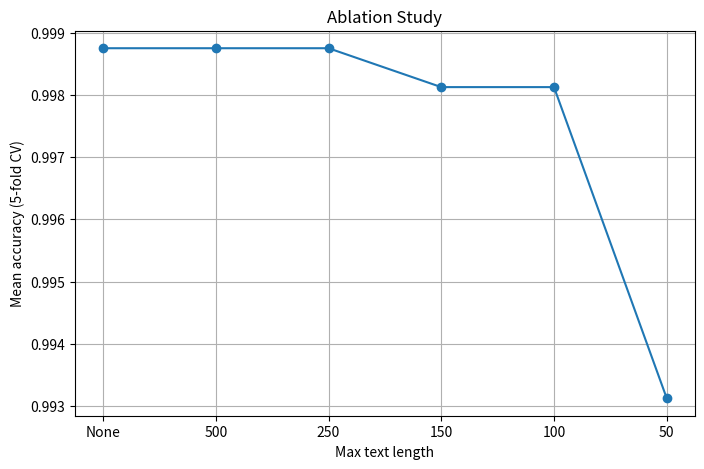

In [31]:
# Plot how the mean accuracy changes with different maximum text lengths
plt.figure(figsize=(8,5))
plt.plot(results['max_len'].astype(str), results['mean_accuracy'], marker='o')
plt.xlabel("Max text length")
plt.ylabel("Mean accuracy (5-fold CV)")
plt.title("Ablation Study")
plt.grid(True)
plt.show()

📝❓ How does the reduction of training data affect the performance of the classifier? And what could be some possible reasons for this?

✅ As the length of the training texts decreases, the classifier’s performance also drops. Because shorter texts contain less linguistic information, making it harder for the model to capture language-specific patterns and thus to distinguish between different languages. Also, since all texts were truncated to the same maximum length, our "text_length" feature no longer carried useful information, weakening predictions where it had been helpful before.

---

📝❓ Write your lab report here addressing all questions in the notebook

## Final Report
In this work, we performed a language classification task using the `scikit-learn` library. Specifically, we:

1. **Explored** the dataset and created training and test splits for our experiments.
2. **Built** a `LogisticRegression` classifier and engineered relevant features, including `text_length` (the length of each text document) and TF-IDF character n-gram vectorization features.
3. **Performed** hyperparameter tuning of the regularization strength and solver type to identify the optimal configuration for our model.
4. **Analyzed** the model's predictions and conducted an error analysis to understand its main failure cases.
5. **Performed** an interpretability analysis using `SHAP` to investigate the most influential features driving the model's decisions.
6. **Conducted** an ablation study on the text length, focusing on Icelandic and Swedish to assess its impact.

---

### 1.1 Exploring the training data
* **Classification challenges**:
The languages that share significant linguistic similarities in vocabulary and grammar might be challenging to distinguish for a simple classification algorithm.

* **Dataset balance**:
Each label has 500 samples in both the training and test sets. We would claim that the dataset is perfectly balanced across all classes.

* **Train/test split**:
The test data is representative of the training data, as the test set covers all classes from the training set, each class has an equal number of examples, and every row includes both text and label with no missing values. However, a 50/50 split leaves too little data for training and more test data to evaluate the performance than actually is needed. To fix this, we concatenate the current train and test sets, then perform a new random 80/20 split and stratify by label for keep class balance.

---

### 3.2 Best Model Selection
* **Best hyperparameters**:
The best performing model used no penalty and 'newton-sg' solver.

* **GridsearchCV advantage**: Grid search with cross-validation evaluates each hyperparameter across multiple folds, so every sample is used for validation exactly once. This process helps select hyperparameters that are less influenced by split-specific variance, thus leading to better generalization.

---

### 3.3 Model Evaluation
* **Test dataset performance**:
The model performs very well on the held-out test set, exceeding **0.98** in accuracy, precision, recall, and F1 score.

---

### 4.1 Error Analysis
* **Strengths and weaknesses**:
The model performs exceptionally well across nearly all languages, as evidenced by the diagonal values ranging between 189 and 200 out of 200. Languages with distinct alphabets or unique characters are classified almost perfectly, e.g. Thai (`tha`). Among Latin-based languages, the strong diagonal dominance remains, though a few noticeable off-diagonal values reveal where the model struggles. For instance, confusion occurs between Danish (`dan`) and Norwegian (`nob`), as well as between Latin (`lat`) and Italian (`ita`), which was expected given their similarities.

* **Reasons of failures**:
The model likely struggles in these cases because the languages share the same alphabet and have very similar grammar, which makes their character patterns overlap in the TF-IDF features. Additionally, these misclassified texts may simply be too short to contain enough distinctive information to identify the language.

---

### 5.1 Interpretability Analysis
* **Feature importance**:
The outputs of the TF-IDF vectorizer mainly appear to be more influential overall than the additional "text length" feature. However, for Japanese, text length emerges as the most influential feature, and for Norwegian and Swedish, it still ranks among the top 20. This pattern makes sense: as discussed earlier, in glyph languages like Japanese, a single glyph has more meaning than an individual letter in alphabetic languages, thus, the length of Japanese texts becomes shorter. Similarly, we assume, since Swedish and Norwegian tend to combine several words into a single word, much like German, this leads to longer texts. At the end, our TF-IDF vectorizer effectively captures alphabets and characteristic symbol n-grams which are important for language identification. For instance, one can observe that the vectorizer features corresponding to characters or n-grams of the respective languages receive high SHAP values — for example, the character `の` for Japanese and the diacritic letter `å` for Swedish.

---

### 6.1 Ablation Study
* **Impact of text reduction**:
As the length of the training texts decreases, the classifier’s performance also drops. Because shorter texts contain less linguistic information, making it harder for the model to capture language-specific patterns and thus to distinguish between different languages. Also, since all texts were truncated to the same maximum length, our "text_length" feature no longer carried useful information, weakening predictions where it had been helpful before.


